In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv


# Employee Attrition Prediction using Machine Learning

## Internship Project - Week 2

### Objective

Employee attrition is one of the major challenges faced by organizations as losing experienced employees leads to increased recruitment costs, training expenses, reduced productivity, and knowledge loss.

The objective of this project is to build a Machine Learning model capable of predicting whether an employee is likely to leave the company based on various employee-related factors such as job satisfaction, monthly income, work-life balance, job role, years at the company, and several other HR attributes.

This notebook covers:

- Data Loading
- Data Cleaning & Preprocessing
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Machine Learning Model Building
- Model Evaluation
- Business Insights & HR Recommendations



In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)


sns.set(style="whitegrid")



In [29]:
import os


os.makedirs("/kaggle/working/charts", exist_ok=True)

print("Charts folder created successfully!")

Charts folder created successfully!


# Data Loading & Initial Exploration

Data loaded using pandas

In [4]:
df = pd.read_csv("/kaggle/input/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv")

Display first 10 rows 

In [5]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [6]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 1470
Columns : 35


Rows : 1470 , 
Columns : 35

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

 Target Column

In [8]:
print(df["Attrition"].value_counts())

Attrition
No     1233
Yes     237
Name: count, dtype: int64


employee left - 237 
employee stayed - 1233

In [9]:
attrition_counts = df["Attrition"].value_counts()

attrition_rate = (
    attrition_counts["Yes"] /
    len(df)
)*100

print(f"Attrition Rate : {attrition_rate:.2f}%")

Attrition Rate : 16.12%


Attrition Rate : 16.12%

Numeric and Categorical Columns

In [10]:
numeric_columns = df.select_dtypes(include=np.number).columns

categorical_columns = df.select_dtypes(exclude=np.number).columns

print("Numeric Columns :", len(numeric_columns))
print("Categorical Columns :", len(categorical_columns))

print("\nNumeric Features\n")
print(numeric_columns.tolist())

print("\nCategorical Features\n")
print(categorical_columns.tolist())

Numeric Columns : 26
Categorical Columns : 9

Numeric Features

['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical Features

['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


### Observation

- The overall attrition rate is **16.12%**, indicating that employee attrition is relatively low.
- Since only about **16%** of employees have left the organization while nearly **84%** have stayed, the dataset is **imbalanced**. This imbalance should be considered during model training by using techniques such as `class_weight='balanced'` to improve prediction of employees likely to leave.

# Data Cleaning & Preprocessing


In [11]:
missing_values = df.isnull().sum()

missing_values

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

No missing values 

In [12]:
columns_to_drop = [
    "EmployeeNumber",
    "EmployeeCount",
    "Over18",
    "StandardHours"
]

df = df.drop(columns=columns_to_drop)

print("Updated Shape :", df.shape)

Updated Shape : (1470, 31)


In [ ]:
dropped 4 irrelevant columns 

encode target variable

In [13]:
df["Attrition"] = df["Attrition"].map({
    "Yes":1,
    "No":0
})

df["Attrition"].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [14]:
# Separate Features and Target Variable 
X = df.drop("Attrition", axis=1)

y = df["Attrition"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (1470, 30)
Target Shape : (1470,)


In [15]:
# Identify Categorical and Numerical columns 
categorical_features = X.select_dtypes(include="object").columns.tolist()

numerical_features = X.select_dtypes(include=np.number).columns.tolist()

print("Categorical Features :", len(categorical_features))
print("Numerical Features :", len(numerical_features))

Categorical Features : 7
Numerical Features : 23


In [16]:
# One-hot encoding and feature scaling 
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing Pipeline Created Successfully.")

Preprocessing Pipeline Created Successfully.


# Exploratory Data Analysis - EDA


Attrition Rate by Department 

In [17]:
department_attrition = (
    df.groupby("Department")["Attrition"]
      .mean()
      .sort_values(ascending=False) * 100
)

department_attrition

Department
Sales                     20.627803
Human Resources           19.047619
Research & Development    13.839750
Name: Attrition, dtype: float64

sales department loses most employee

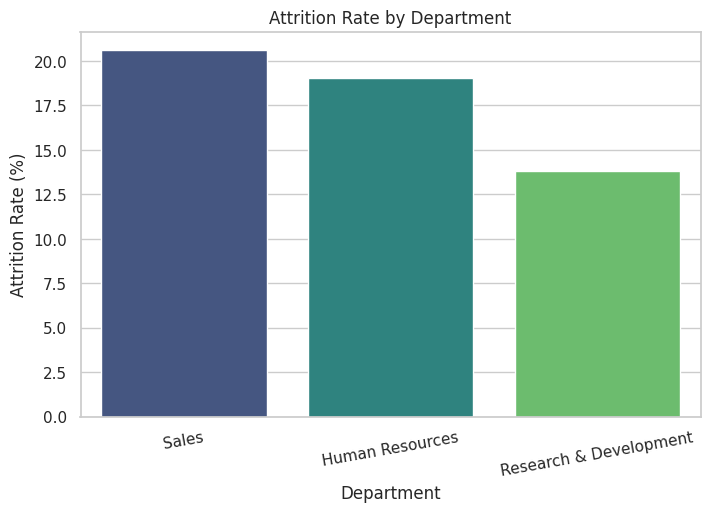

In [37]:
# Visualization
plt.figure(figsize=(8,5))

sns.barplot(
    x=department_attrition.index,
    y=department_attrition.values,
    palette="viridis"
)

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")

plt.xticks(rotation=10)
plt.savefig("/kaggle/working/charts/department_attrition.png", dpi=300, bbox_inches="tight")

plt.show()


Attrition Rate by Job Role

In [19]:
jobrole_attrition = (
    df.groupby("JobRole")["Attrition"]
      .mean()
      .sort_values(ascending=False) * 100
)

jobrole_attrition

JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: Attrition, dtype: float64

sales representative have the highest exit rate

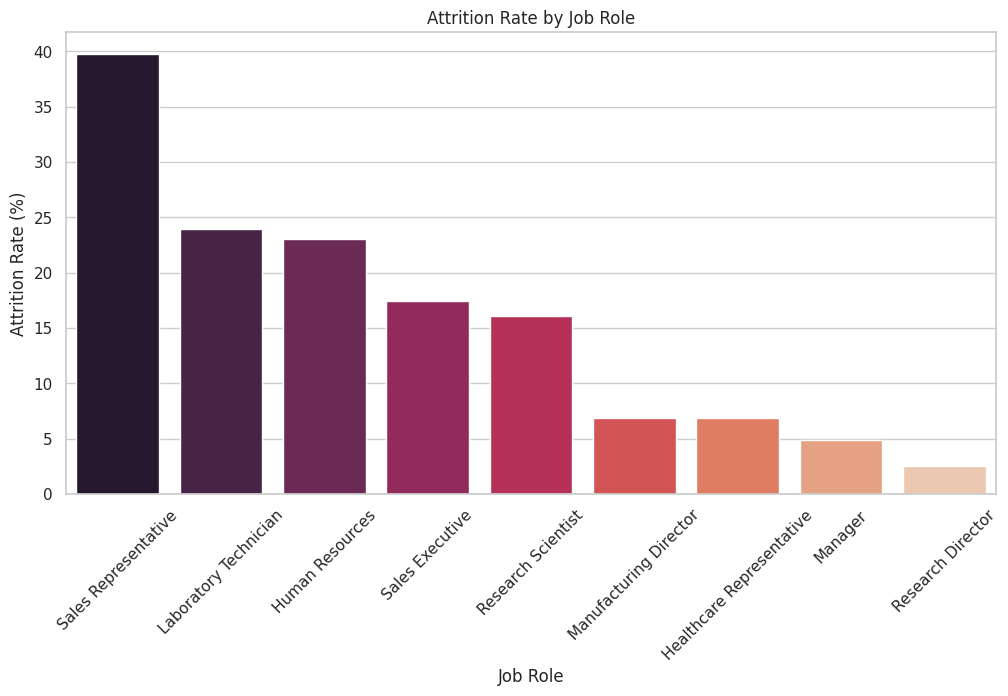

In [38]:
# Visualization
plt.figure(figsize=(12,6))

sns.barplot(
    x=jobrole_attrition.index,
    y=jobrole_attrition.values,
    palette="rocket"
)

plt.title("Attrition Rate by Job Role")

plt.xlabel("Job Role")

plt.ylabel("Attrition Rate (%)")

plt.xticks(rotation=45)
plt.savefig("/kaggle/working/charts/jobrole_attrition.png",
            dpi=300,
            bbox_inches="tight")

plt.show() 



Attrition vs Monthly Income

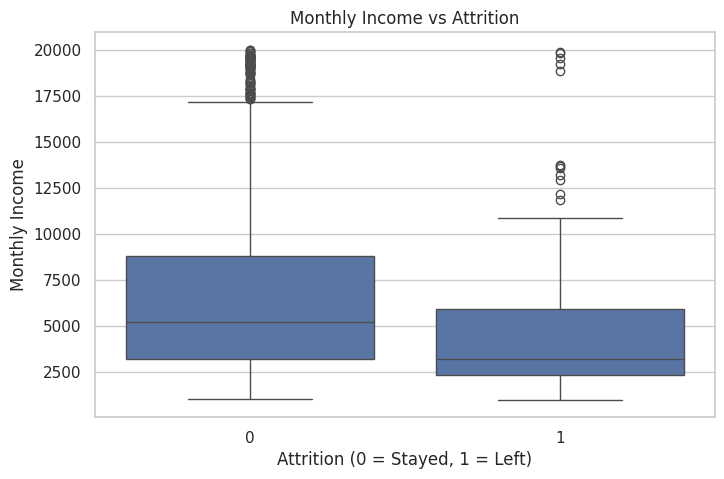

In [39]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    data=df
)

plt.title("Monthly Income vs Attrition")

plt.xlabel("Attrition (0 = Stayed, 1 = Left)")

plt.ylabel("Monthly Income")
plt.savefig("/kaggle/working/charts/monthly_income_boxplot.png",
            dpi=300,
            bbox_inches="tight")

plt.show()



yes the less payed empoyee leave the more 

Attrition vs Work-Life Balance

In [22]:
worklife_attrition = (
    df.groupby("WorkLifeBalance")["Attrition"]
      .mean()
      .sort_index() * 100
)

worklife_attrition

WorkLifeBalance
1    31.250000
2    16.860465
3    14.221725
4    17.647059
Name: Attrition, dtype: float64

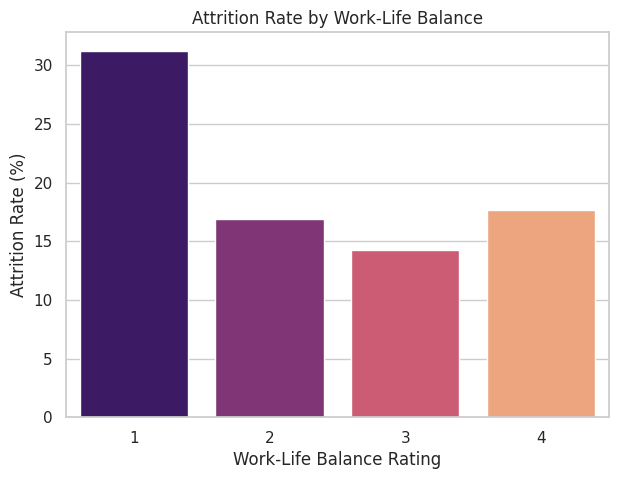

In [40]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=worklife_attrition.index,
    y=worklife_attrition.values,
    palette="magma"
)

plt.title("Attrition Rate by Work-Life Balance")

plt.xlabel("Work-Life Balance Rating")

plt.ylabel("Attrition Rate (%)")
plt.savefig("/kaggle/working/charts/worklife_balance.png",
            dpi=300,
            bbox_inches="tight")

plt.show()




yes we can see that better worklife balance have less attrition rate but at some point further they again have slightly higher attrition rate 

Attrition vs Years at Company

In [24]:
years_attrition = (
    df.groupby("YearsAtCompany")["Attrition"]
      .mean() * 100
)

years_attrition.head()

YearsAtCompany
0    36.363636
1    34.502924
2    21.259843
3    15.625000
4    17.272727
Name: Attrition, dtype: float64

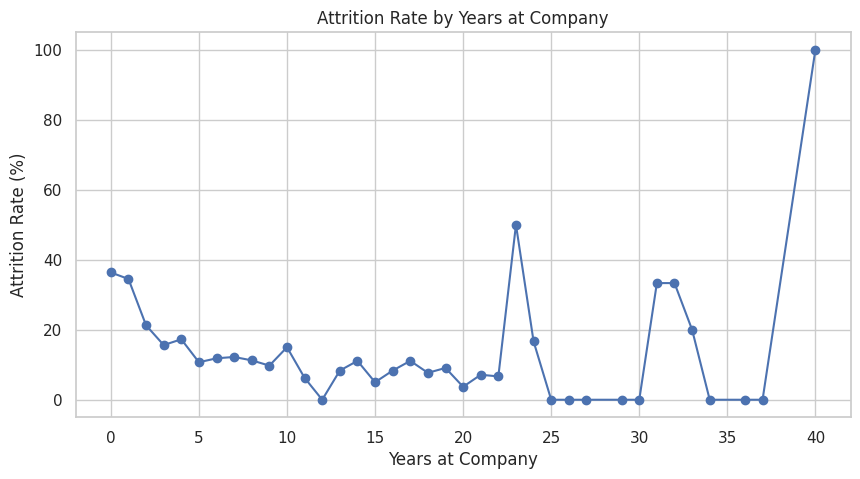

In [41]:
plt.figure(figsize=(10,5))

plt.plot(
    years_attrition.index,
    years_attrition.values,
    marker="o"
)

plt.title("Attrition Rate by Years at Company")

plt.xlabel("Years at Company")

plt.ylabel("Attrition Rate (%)")

plt.grid(True)
plt.savefig("/kaggle/working/charts/years_at_company.png",
            dpi=300,
            bbox_inches="tight")

plt.show() 


attrition rate is higher at the beggining year and after 40 years 

Correlation Heatmap of Numerical Features

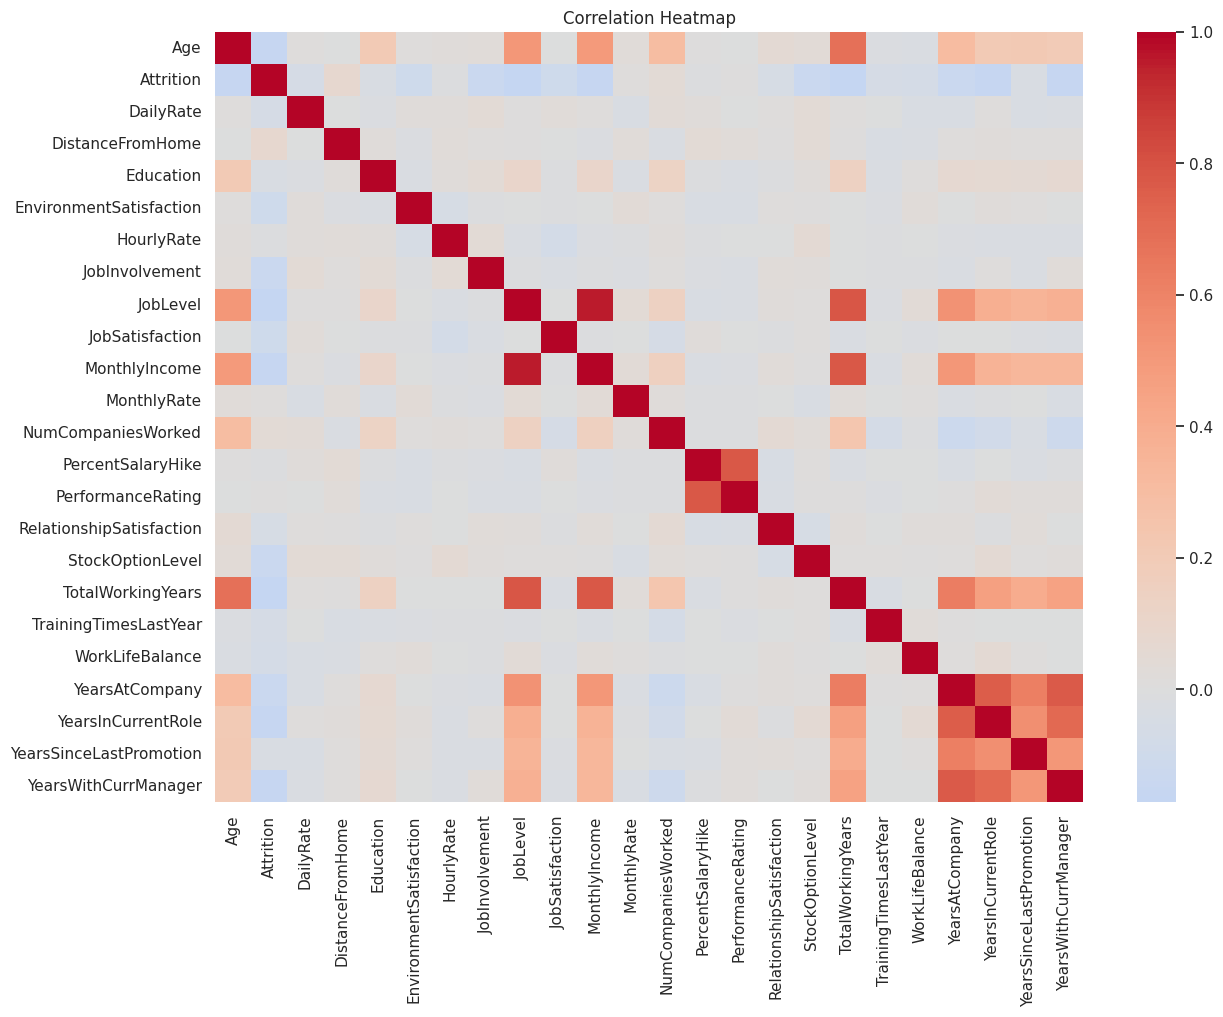

In [26]:
plt.figure(figsize=(14,10))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

## Business Insights from EDA

###  1: Sales department experiences the highest employee attrition.

The **Sales department records an attrition rate of 20.63%**, which is higher than **Human Resources (19.05%)** and significantly higher than **Research & Development (13.84%)**. This suggests that retention efforts should primarily focus on employees working in Sales.

---

### 2: Sales Representatives are the most likely employees to leave.

Among all job roles, **Sales Representatives have the highest attrition rate at 39.76%**, followed by **Laboratory Technicians (23.94%)** and **Human Resources employees (23.08%)**. Nearly **4 out of every 10 Sales Representatives leave the organization**, making this role a high-risk category for employee turnover.

---

###  3: Employees with lower monthly income tend to leave more frequently.

The Monthly Income box plot shows that employees who left the company generally earned **lower salaries** than employees who stayed. Although salary is not the only factor influencing attrition, lower income appears to be associated with a higher likelihood of employees leaving the organization.

---

###  4: Poor work-life balance is associated with higher attrition.

Employees with a **Work-Life Balance rating of 1** have an attrition rate of **31.25%**, which is almost **double** the rate of employees with ratings **2 (16.86%)** and **3 (14.22%)**. This suggests that improving employees' work-life balance may significantly reduce employee turnover.

---

### 5: Attrition is highest during the early years of employment.

Employees with **0 years (36.36%)** and **1 year (34.50%)** of service have the highest attrition rates. This indicates that many employees leave during the first few years after joining the company, suggesting that onboarding, mentoring, and early career support programs could improve employee retention.

# Model Building & Comparison


Train Test Split 

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples : (1176, 30)
Testing Samples : (294, 30)


Created model using class weight balance 

In [43]:
from sklearn.pipeline import Pipeline

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        random_state=42,
        max_iter=1000
    ))
])

random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42
    ))
])

gradient_boosting_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        random_state=42
    ))
])

Train models 

In [44]:

logistic_model.fit(X_train, y_train)


random_forest_model.fit(X_train, y_train)


gradient_boosting_model.fit(X_train, y_train)

print("All models trained successfully!")

All models trained successfully!


Predictions 

In [45]:
lr_pred = logistic_model.predict(X_test)
rf_pred = random_forest_model.predict(X_test)
gb_pred = gradient_boosting_model.predict(X_test)

In [46]:
lr_prob = logistic_model.predict_proba(X_test)[:,1]

rf_prob = random_forest_model.predict_proba(X_test)[:,1]

gb_prob = gradient_boosting_model.predict_proba(X_test)[:,1]

Model Comparison Table 

In [47]:
comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Accuracy":[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ],

    "Precision":[
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)
    ],

    "Recall":[
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)
    ],

    "F1 Score":[
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred)
    ],

    "ROC-AUC":[
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, gb_prob)
    ]
})

comparison = comparison.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Gradient Boosting,0.860544,0.714286,0.212766,0.327869,0.805065
1,Logistic Regression,0.751701,0.348837,0.638298,0.451128,0.803170
2,Random Forest,0.846939,0.625000,0.106383,0.181818,0.783185


# Model Evaluation 

 Classification Report

In [50]:
print("Logistic Regression")


print(classification_report(y_test, lr_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.92      0.77      0.84       247
           1       0.35      0.64      0.45        47

    accuracy                           0.75       294
   macro avg       0.63      0.71      0.65       294
weighted avg       0.83      0.75      0.78       294



In [51]:

print("Random Forest")


print(classification_report(y_test, rf_pred))

Random Forest
              precision    recall  f1-score   support

           0       0.85      0.99      0.92       247
           1       0.62      0.11      0.18        47

    accuracy                           0.85       294
   macro avg       0.74      0.55      0.55       294
weighted avg       0.82      0.85      0.80       294



In [52]:

print("Gradient Boosting")

print(classification_report(y_test, gb_pred))

Gradient Boosting
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       247
           1       0.71      0.21      0.33        47

    accuracy                           0.86       294
   macro avg       0.79      0.60      0.63       294
weighted avg       0.84      0.86      0.83       294



ROC-AUC Score Comparison

In [53]:
roc_scores = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "ROC-AUC":[
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, gb_prob)
    ]
})

roc_scores.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,ROC-AUC
2,Gradient Boosting,0.805065
0,Logistic Regression,0.803170
1,Random Forest,0.783185


best_model

In [56]:
best_model_name = comparison.iloc[0]["Model"]

print("Best Model :", best_model_name)

Best Model : Gradient Boosting


In [55]:
if best_model_name == "Logistic Regression":
    best_model = logistic_model
    best_predictions = lr_pred

elif best_model_name == "Random Forest":
    best_model = random_forest_model
    best_predictions = rf_pred

else:
    best_model = gradient_boosting_model
    best_predictions = gb_pred

Confusion matrix

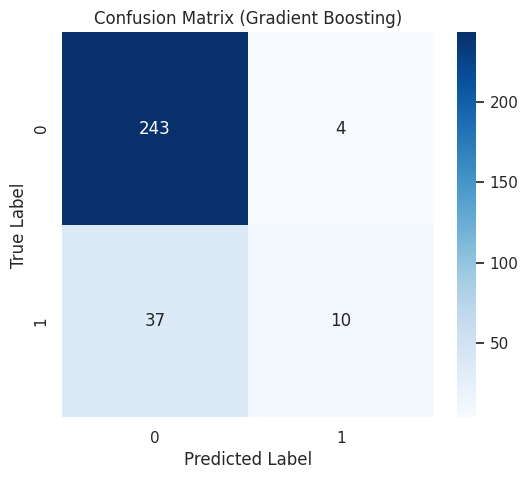

In [57]:
cm = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(f"Confusion Matrix ({best_model_name})")

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.savefig(
    "/kaggle/working/charts/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

Feature Importance 

In [58]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

In [59]:
classifier = best_model.named_steps["classifier"]

if hasattr(classifier, "feature_importances_"):

    importance = classifier.feature_importances_

else:

    importance = np.abs(classifier.coef_[0])

In [60]:
importance_df = pd.DataFrame({

    "Feature":feature_names,

    "Importance":importance

})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
9,num__MonthlyIncome,0.103979
0,num__Age,0.100139
16,num__TotalWorkingYears,0.083014
50,cat__OverTime_Yes,0.054745
15,num__StockOptionLevel,0.049619
11,num__NumCompaniesWorked,0.048832
22,num__YearsWithCurrManager,0.044950
1,num__DailyRate,0.042605
4,num__EnvironmentSatisfaction,0.040158
6,num__JobInvolvement,0.039142


In [63]:
# top 10 features
top10 = importance_df.head(10)

top10

,Feature,Importance
9,num__MonthlyIncome,0.103979
0,num__Age,0.100139
16,num__TotalWorkingYears,0.083014
50,cat__OverTime_Yes,0.054745
15,num__StockOptionLevel,0.049619
11,num__NumCompaniesWorked,0.048832
22,num__YearsWithCurrManager,0.044950
1,num__DailyRate,0.042605
4,num__EnvironmentSatisfaction,0.040158
6,num__JobInvolvement,0.039142


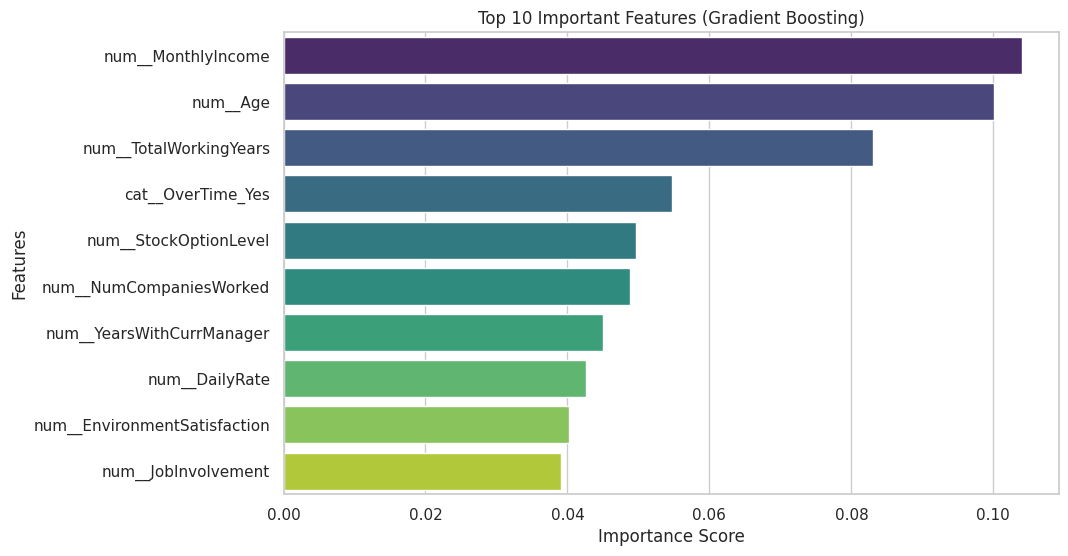

In [62]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title(f"Top 10 Important Features ({best_model_name})")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.savefig(
    "/kaggle/working/charts/top10_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# Visualization

### Chart 1: Attrition Rate by Department and Job Role

The following bar charts compare employee attrition across different departments and job roles to identify areas with the highest employee turnover.

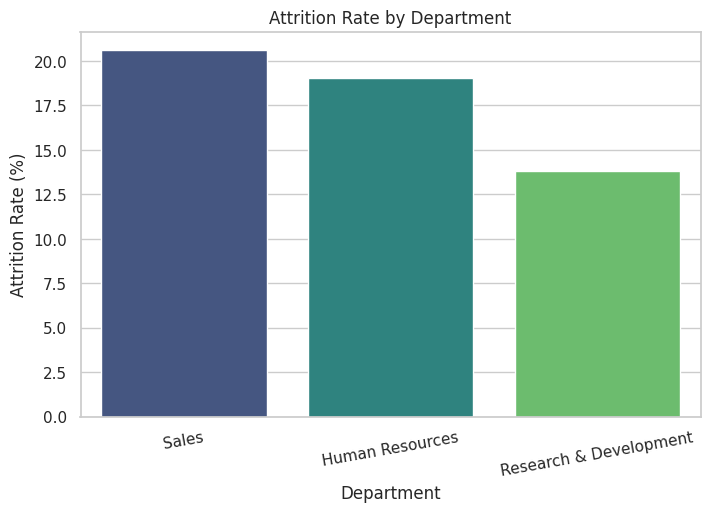

In [64]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=department_attrition.index,
    y=department_attrition.values,
    palette="viridis"
)

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")

plt.xticks(rotation=10)
plt.savefig("/kaggle/working/charts/department_attrition.png", dpi=300, bbox_inches="tight")

plt.show()


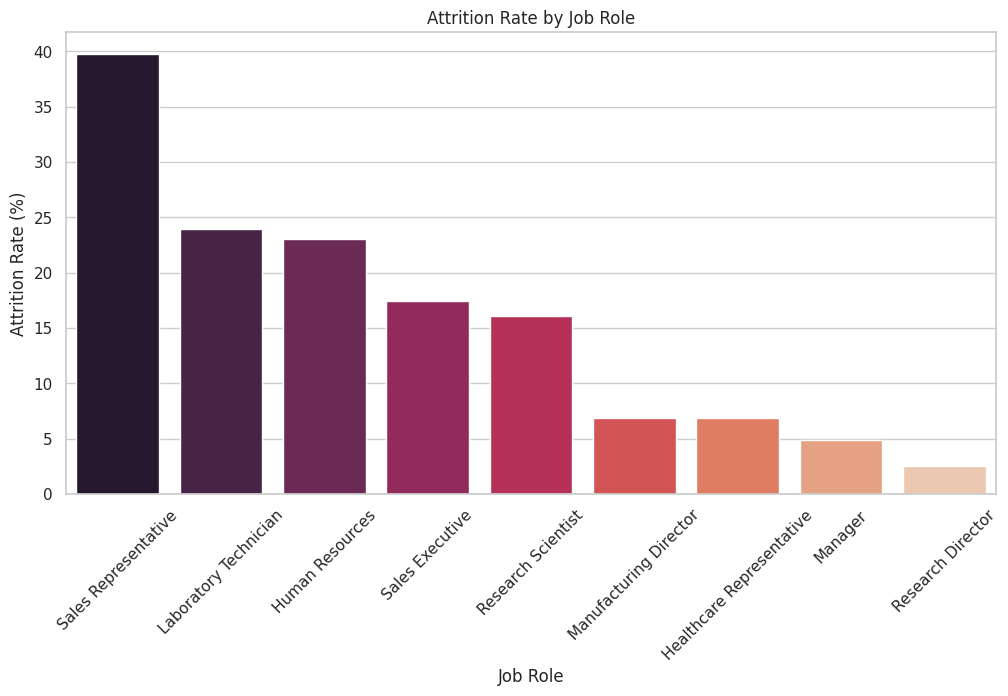

In [65]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=jobrole_attrition.index,
    y=jobrole_attrition.values,
    palette="rocket"
)

plt.title("Attrition Rate by Job Role")

plt.xlabel("Job Role")

plt.ylabel("Attrition Rate (%)")

plt.xticks(rotation=45)
plt.savefig("/kaggle/working/charts/jobrole_attrition.png",
            dpi=300,
            bbox_inches="tight")

plt.show() 


### Chart 2: Monthly Income vs Attrition

The box plot compares the salary distributions of employees who stayed and those who left the company.

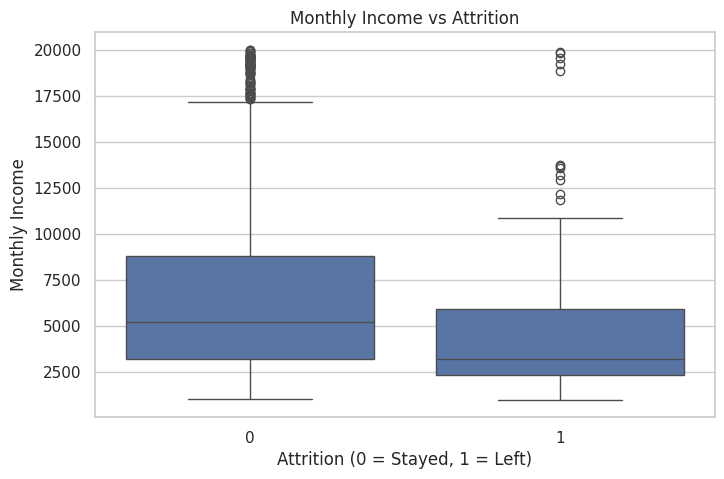

In [66]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    data=df
)

plt.title("Monthly Income vs Attrition")

plt.xlabel("Attrition (0 = Stayed, 1 = Left)")

plt.ylabel("Monthly Income")
plt.savefig("/kaggle/working/charts/monthly_income_boxplot.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### Chart 3: Confusion Matrix of Best Model

The confusion matrix summarizes the prediction performance of the best-performing machine learning model.

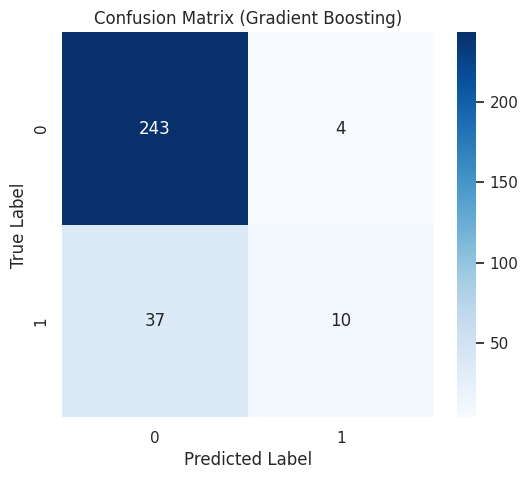

In [67]:
cm = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(f"Confusion Matrix ({best_model_name})")

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.savefig(
    "/kaggle/working/charts/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Chart 4: Top 10 Feature Importances

The following chart highlights the most influential factors contributing to employee attrition prediction.

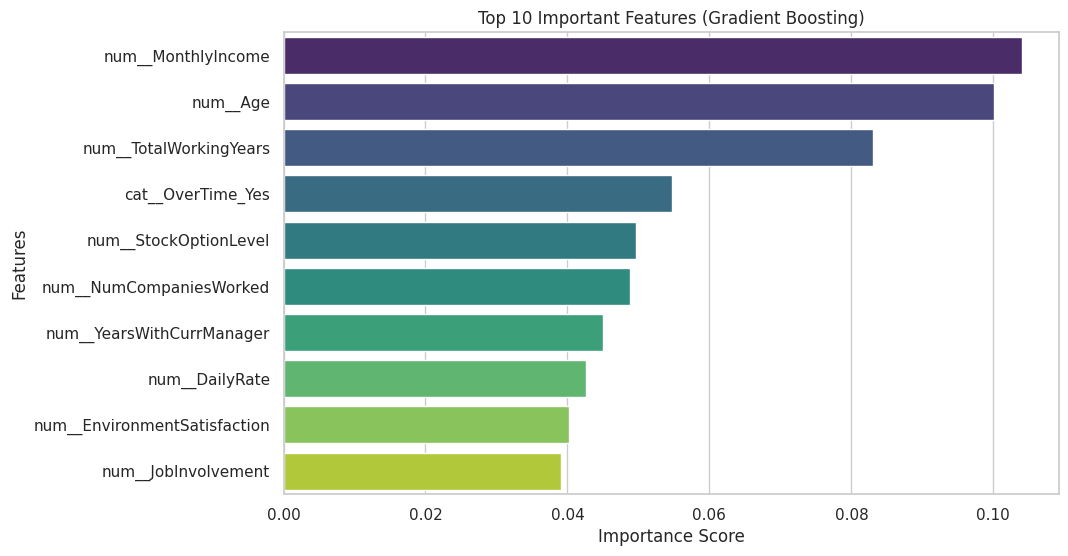

In [68]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title(f"Top 10 Important Features ({best_model_name})")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.savefig(
    "/kaggle/working/charts/top10_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Chart 5 (Bonus): ROC Curve Comparison

The Receiver Operating Characteristic (ROC) Curve compares the classification performance of all three machine learning models across different decision thresholds.

A curve closer to the upper-left corner indicates better discrimination between employees who stay and those who leave.

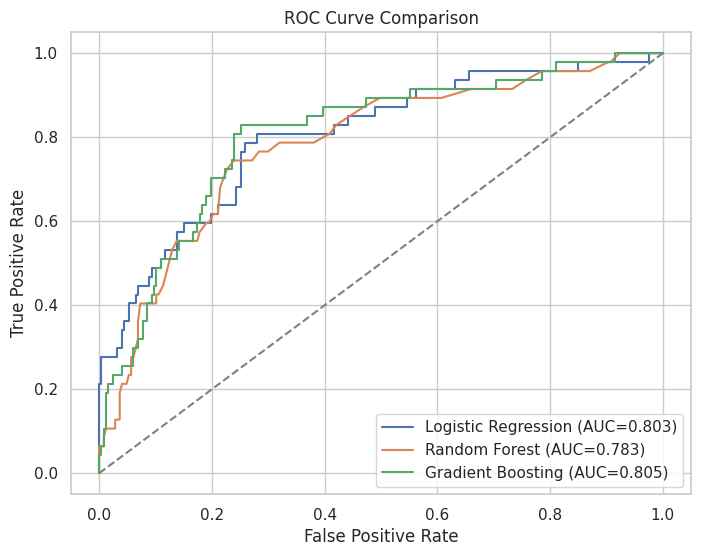

In [69]:
from sklearn.metrics import roc_curve



lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_prob)

plt.figure(figsize=(8,6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression (AUC={roc_auc_score(y_test, lr_prob):.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC={roc_auc_score(y_test, rf_prob):.3f})"
)

plt.plot(
    gb_fpr,
    gb_tpr,
    label=f"Gradient Boosting (AUC={roc_auc_score(y_test, gb_prob):.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.grid(True)

plt.savefig(
    "/kaggle/working/charts/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# HR Insights & Business Recommendations

Based on the analysis, the three strongest indicators of employee attrition are **job role, work-life balance, and years at the company**. Sales Representatives and employees in the Sales department show the highest attrition rates, so HR should prioritize retention efforts for these groups. While employees with lower monthly income are more likely to leave, salary alone does not explain attrition; factors such as poor work-life balance and early-stage tenure also play a significant role. HR should introduce targeted onboarding and mentoring programs for employees during their first two years and conduct regular retention discussions with employees in high-risk job roles, particularly in the Sales department. Additionally, improving work-life balance through flexible work policies and employee well-being initiatives may help reduce employee turnover. One limitation of this model is that it is trained on historical employee data and cannot capture personal circumstances or future organizational changes that may influence an employee's decision to leave.
